In [1]:
import logging
from pathlib import Path
from onlinediar.diarizer import Diarizer

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('diarization_batch.log'),
        logging.StreamHandler()
    ]
)

model_dir = Path("./models")
emb_model_path = model_dir / "voxblink2_samresnet34_ft.onnx"
pca_path = model_dir / "pca_model_128d.joblib"

diarizer = Diarizer(
    backend="csea",
    emb_model_path=str(emb_model_path),
    csea_threshold=0.68,
    max_embeddings_per_speaker=40,
    resample_rate=16000,
    device="cuda",
    use_pca=True,
    pca_path=str(pca_path),
    log_level=logging.INFO
)

audio_files = [
    Path(r"/home/jovyan/polevoi-av/online-diar/diar_date/audio/1870922517105_cropped.wav")
]

for audio_file in audio_files:
    logging.info(f"Diarization is started for file: {audio_file.name}")
    annotation = diarizer.diarize(str(audio_file))

    rttm_path = audio_file.with_suffix('.rttm')
    audio_uri = audio_file.stem  

    diarizer.save_rttm(annotation, str(rttm_path), audio_uri=audio_uri)
    logging.info(f"Save RTTM: {rttm_path}")

2026-01-15 23:55:34,783 - Diarizer - INFO - Initializing CSEA diarization backend
2026-01-15 23:55:34,783 - Diarizer - INFO - Initializing CSEA diarization backend
[ INFO : 2026-01-15 23:55:34,878 ] - Loading embedding model from: models/voxblink2_samresnet34_ft.onnx
2026-01-15 23:55:34,878 - Pyobj, f - INFO - Loading embedding model from: models/voxblink2_samresnet34_ft.onnx
[ INFO : 2026-01-15 23:55:35,923 ] - Embedding model loaded successfully from onnx
2026-01-15 23:55:35,923 - Pyobj, f - INFO - Embedding model loaded successfully from onnx
[ INFO : 2026-01-15 23:55:35,924 ] - PCA is used
2026-01-15 23:55:35,924 - Pyobj, f - INFO - PCA is used
/home/jovyan/polevoi-av/online-diar/venv_diar/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.7.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/mod

In [2]:
# import logging
# from pathlib import Path
# from onlinediar.diarizer import Diarizer

# logging.basicConfig(
#     level=logging.INFO,
#     format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
#     handlers=[
#         logging.FileHandler('diarization_streaming_cos.log'),
#         logging.StreamHandler()
#     ]
# )

# diarizer = Diarizer(
#         backend="csea",
#         emb_model_path="models/voxblink2_samresnet34_ft.onnx",
#         csea_threshold=0.68,
#         max_embeddings_per_speaker=40,
#         resample_rate=16000,
#         device="cpu",
#         use_pca=True,
#         pca_path="models/pca_model_128d.joblib",
#         log_level=logging.INFO
#     )

# diarizer.stream_from_microphone(
#         save_audio=True,
#         output_prefix="csea_stream",
#         show_realtime_results=True,
#         block_size=4096
#     )

In [3]:
# import logging
# from pathlib import Path
# from onlinediar.diarizer import Diarizer

# logging.basicConfig(
#     level=logging.INFO,
#     format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
#     handlers=[
#         logging.FileHandler('diarization_streaming_psda.log'),
#         logging.StreamHandler()
#     ]
# )

# diarizer = Diarizer(
#         backend="psda",
#         emb_model_path="models/voxblink2_samresnet34_ft.onnx",
#         psda_path="models/voxblinkR34_ft/psda_vox_128_2sec",
#         online_psda_threshold=-30.0,
#         resample_rate=16000,
#         device="cpu",
#         use_pca=True,
#         pca_path="models/pca_model_128d.joblib",
#         log_level=logging.INFO
#     )

# diarizer.stream_from_microphone(
#         save_audio=True,
#         output_prefix="csea_stream",
#         show_realtime_results=True,
#         block_size=4096
#     )

# Metrics



In [4]:
from diar_utils import *

In [ ]:
from pyannote.core import Annotation
import pandas as pd


def load_excel_annote(path: str):
    df = pd.read_excel(path)
    annote = Annotation()
    for _, row in df.iterrows():
        start = row['start']
        end = row['end']
        idx = row['id']
        seg = Segment(start=start, end=end)
        annote[seg] =  idx
    return annote



In [10]:
# json_file = r"C:\Users\nicit\Downloads\Telegram Desktop\project-1-at-2025-02-12-04-30-c5db01bf.json"

ResNet34_csea = load_rttm_annote('/home/jovyan/polevoi-av/online-diar/diar_date/audio/1870922517105_cropped.rttm')
ref_file = "diar_date/rttm/1870922517105_cropped.mp4.xlsx"
ref = load_excel_annote(str(ref_file))

# target_annote_1 = load_json_annote(json_data=load_json(json_file), idx=3)
# target_annote_2 = load_json_annote(json_data=load_json(json_file), idx=2)

# pyannote_annote_1 = load_rttm_annote('/home/jovyan/polevoi-av/online-diar/diar_date/rttm/1870922517105_cropped.mp4.xlsx')
# pyannote_annote_2 = load_rttm_annote('rttm_pyannote_2.rttm')

# sortformer_annote_1 = load_pickle('sortformer_annote_1.pkl')
# sortformer_annote_2 =load_pickle('sortformer_annote_2.pkl')

In [ ]:
from pyannote.metrics.diarization import DiarizationErrorRate
der = DiarizationErrorRate()
der(ref, ResNet34_csea, uri='ResNet34')

der.report(display=True)
print()

         diarization error rate   total correct correct false alarm false alarm missed detection missed detection confusion confusion
                              %                       %                       %                                 %                   %
item                                                                                                                                 
ResNet34                   3.03 1080.94 1056.16   97.71        7.96        0.74            17.30             1.60      7.48      0.69
TOTAL                      3.03 1080.94 1056.16   97.71        7.96        0.74            17.30             1.60      7.48      0.69



/home/jovyan/polevoi-av/online-diar/venv_diar/lib/python3.10/site-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(


In [7]:
from pyannote.metrics.diarization import DiarizationErrorRate
der = DiarizationErrorRate()
der(target_annote_2, pyannote_annote_2, uri='pyannote')
der(target_annote_2, ResNet34_annote_2, uri='ResNet34')
der(target_annote_2, sortformer_annote_2, uri='sortformer')
der.report(display=True)
print()

           diarization error rate  total correct correct false alarm false alarm missed detection missed detection confusion confusion
                                %                      %                       %                                 %                   %
item                                                                                                                                  
pyannote                     8.02 221.31  204.01   92.18        0.45        0.20            17.21             7.78      0.09      0.04
ResNet34                     7.10 221.31  209.50   94.66        3.90        1.76             8.45             3.82      3.36      1.52
sortformer                   4.04 221.31  213.42   96.44        1.05        0.47             7.89             3.56      0.00      0.00
TOTAL                        6.39 663.92  626.92   94.43        5.40        0.81            33.55             5.05      3.45      0.52



c:\Users\nicit\Apython\elevenlab-key-burner-bot\.venv\Lib\site-packages\pyannote\metrics\utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(


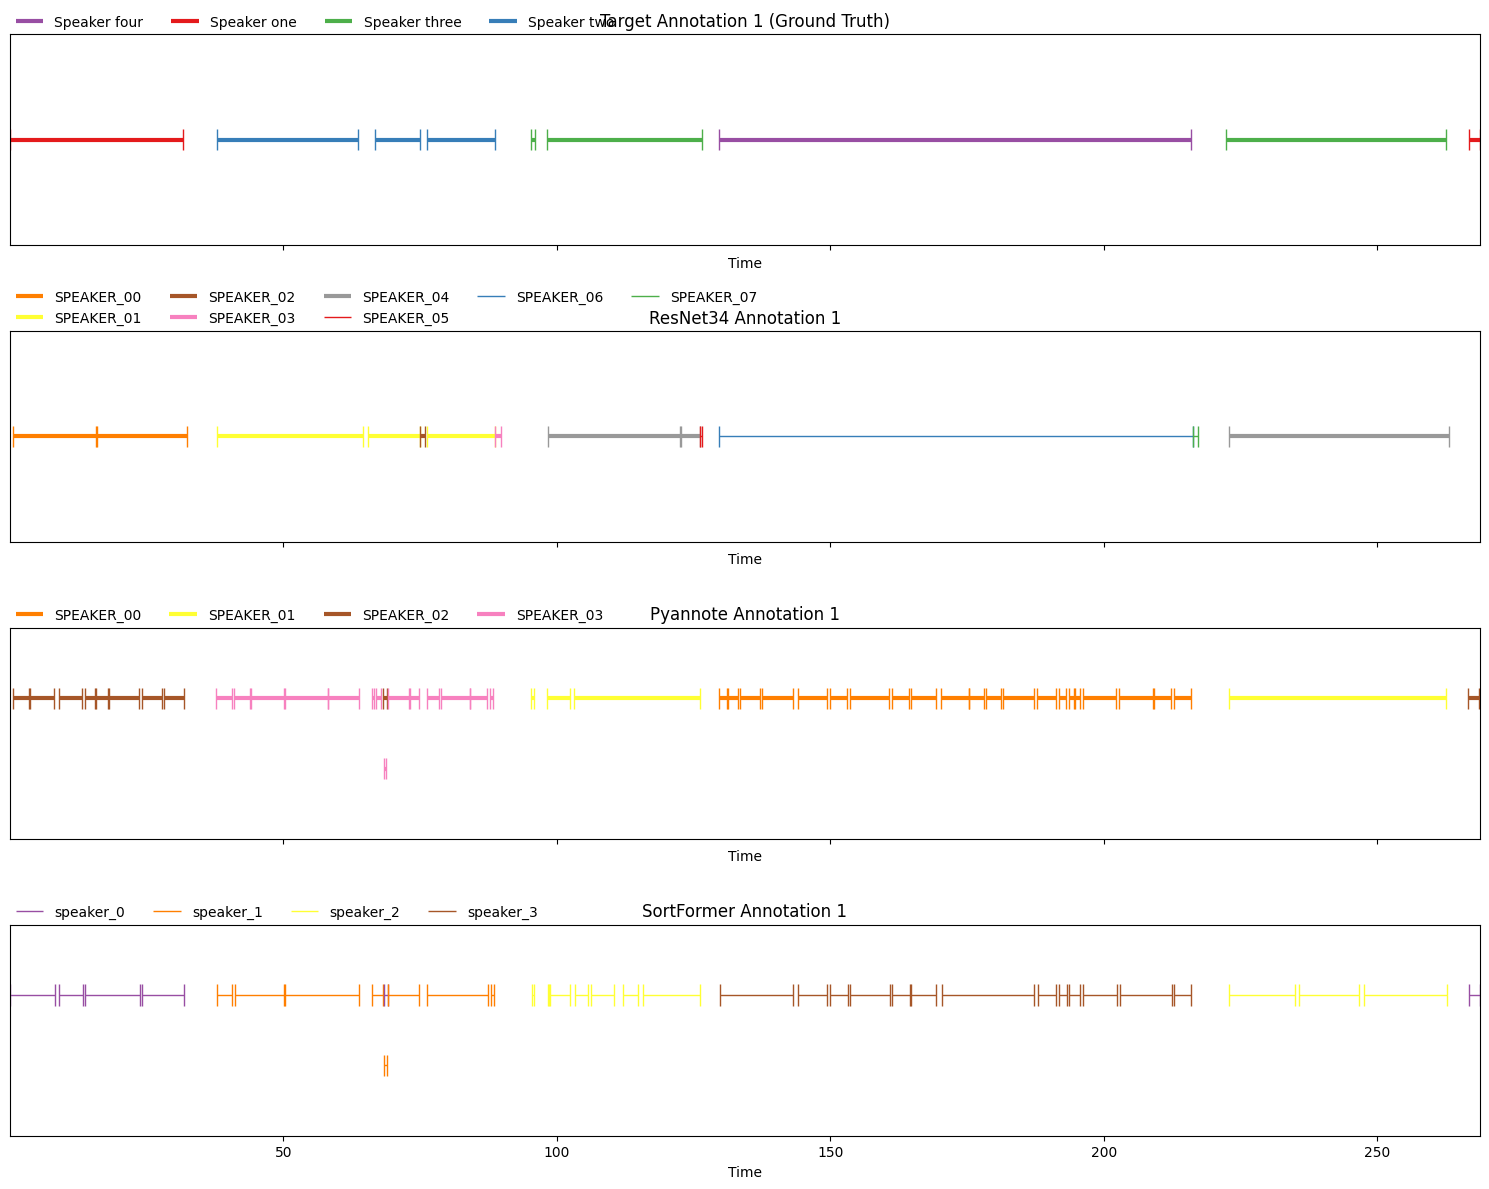

In [8]:
from pyannote.core import  notebook
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

notebook.plot_annotation(target_annote_1, ax=axes[0], time=True)
axes[0].set_title("Target Annotation 1 (Ground Truth)")
notebook.plot_annotation(ResNet34_annote_1, ax=axes[1], time=True)
axes[1].set_title("ResNet34 Annotation 1")
notebook.plot_annotation(pyannote_annote_1, ax=axes[2], time=True)
axes[2].set_title("Pyannote Annotation 1")
notebook.plot_annotation(sortformer_annote_1, ax=axes[3], time=True)
axes[3].set_title("SortFormer Annotation 1")

plt.tight_layout()
plt.show()

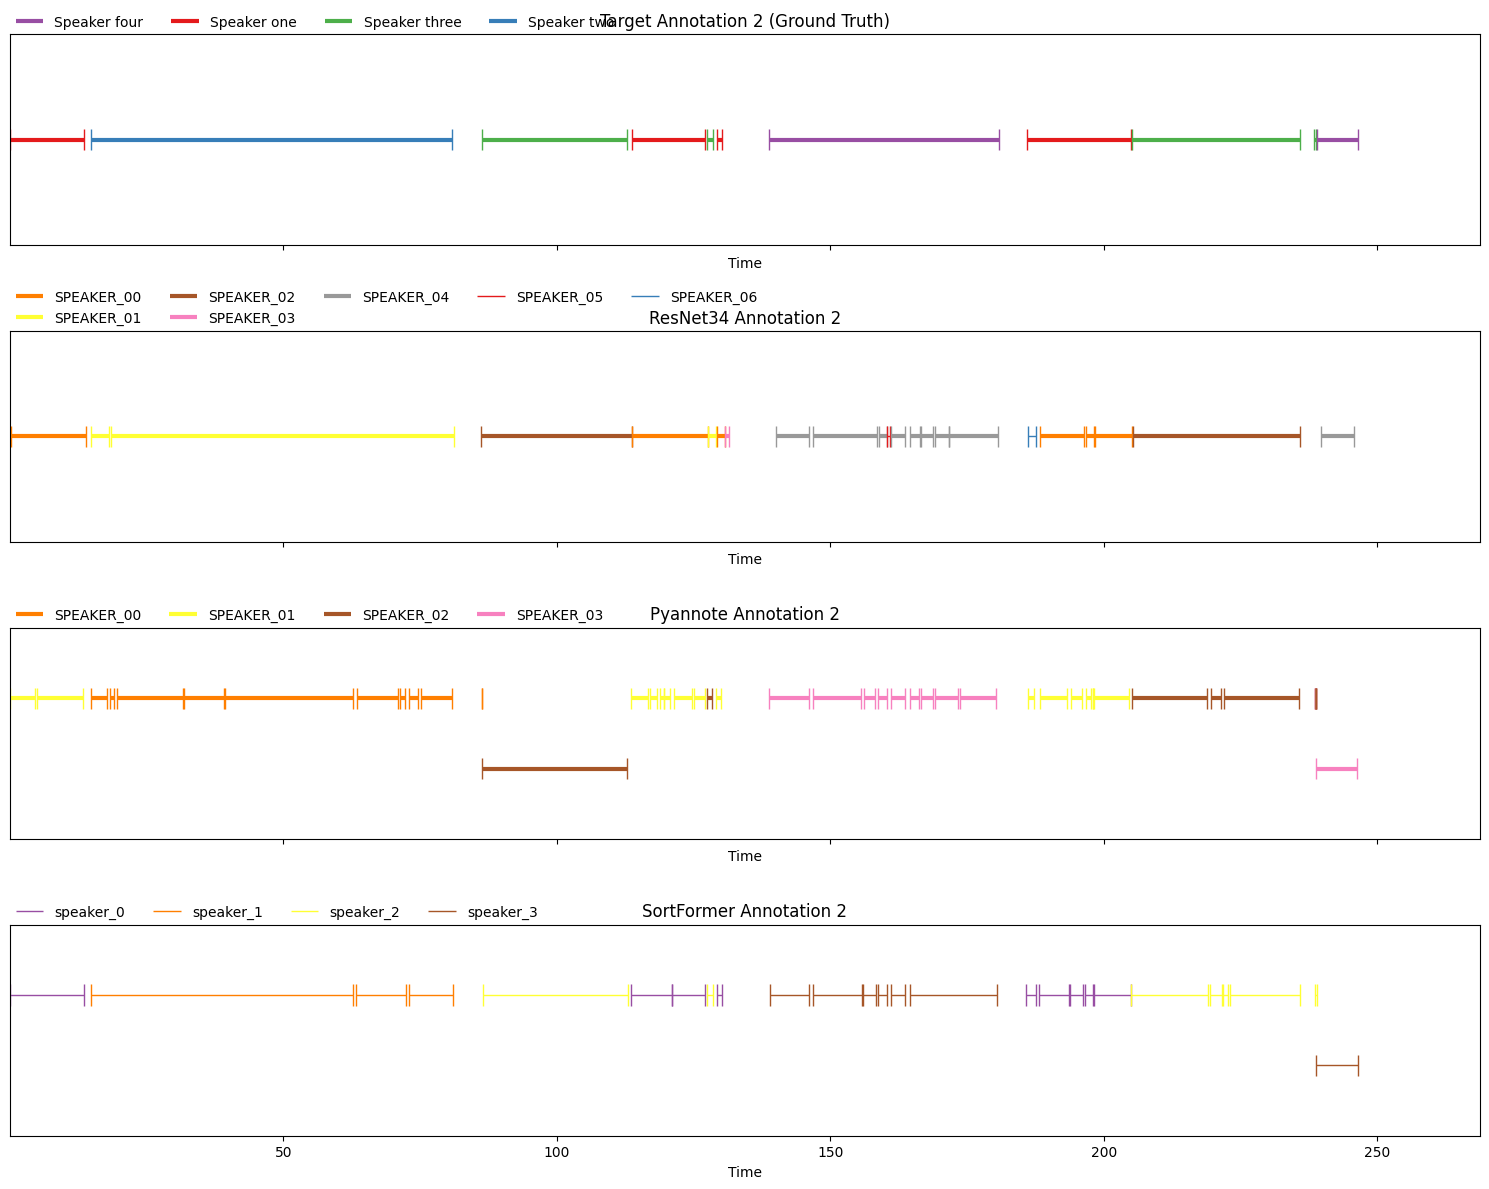

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

notebook.plot_annotation(target_annote_2, ax=axes[0], time=True)
axes[0].set_title("Target Annotation 2 (Ground Truth)")
notebook.plot_annotation(ResNet34_annote_2, ax=axes[1], time=True)
axes[1].set_title("ResNet34 Annotation 2")
notebook.plot_annotation(pyannote_annote_2, ax=axes[2], time=True)
axes[2].set_title("Pyannote Annotation 2")
notebook.plot_annotation(sortformer_annote_2, ax=axes[3], time=True)
axes[3].set_title("SortFormer Annotation 2")

plt.tight_layout()
plt.show()